## Pain ratings variability analysis

### The file contains:
- **Data preprocessing**
- **Calculation and visualization of:**
  - Coefficient of Variance (CV)
- **Average pain ratings**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
import scipy.stats as stats
from scipy.stats import zscore
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import ptitprince as pt
from scipy.stats import kruskal
from statsmodels.formula.api import ols
from scipy.stats import chi2
import ast
from scipy.stats import skew, kurtosis
from scipy.stats import rankdata
from scipy.stats import levene, shapiro
from statsmodels.stats.anova import anova_lm
from scipy.stats import mannwhitneyu
from itertools import combinations
from scipy.stats import norm
from ratings_utils import *

#Please change according to your machine 
user="gaia"

### Data opening

In [2]:
# Extracting groups per subject from second level GLM df
original_groups = pd.read_csv(f"secondlevelGLMdf.csv")
original_groups["group"] = original_groups.iloc[:, -3:].idxmax(axis=1)
subject_group_mapping = original_groups.set_index("Unnamed: 0")["group"]
display(original_groups)

display(original_groups["group"].value_counts())

,Unnamed: 0,visit1,visit2,visit3,visit4,visit5,age,chronic,SBPr,SBPp,group
0,sub-001,True,False,False,True,False,-16.723404,0,1,0,SBPr
1,sub-002,True,False,True,True,False,13.276596,0,1,0,SBPr
2,sub-003,True,True,True,True,True,5.276596,0,1,0,SBPr
3,sub-004,True,True,True,True,False,2.276596,0,1,0,SBPr
4,sub-005,True,True,True,True,False,-13.723404,0,1,0,SBPr
...,...,...,...,...,...,...,...,...,...,...,...
89,sub-117,True,True,True,True,False,6.276596,1,0,0,chronic
90,sub-118,True,True,True,True,False,4.276596,1,0,0,chronic
91,sub-119,True,True,True,False,False,-3.723404,1,0,0,chronic
92,sub-120,True,True,True,True,False,3.276596,1,0,0,chronic


SBPp       43
SBPr       27
chronic    24
Name: group, dtype: int64

In [3]:
#Create a dataframe with subject, visit, pain ratings (in separate columns) for each visit

response_array_df = pd.read_csv("Results/Carl_preprocessed_responses/responseArray.csv",
                                delimiter='\t',
                                header=None)

response_details_df = pd.read_csv("Results/Carl_preprocessed_responses/preprocessed_response_details.csv",
                                  delimiter='\t')

pain_ratings_df = pd.concat([response_details_df, response_array_df], axis=1)


pain_ratings_df

,subject,visit,run,group,0,1,2,3,4,5,...,230,231,232,233,234,235,236,237,238,239
0,sub-001,visit1,run_01,subacute,68.030000,64.690000,60.140000,59.900000,59.960000,56.370000,...,18.110000,20.180000,26.550000,26.430000,26.370000,21.150000,20.970000,21.270000,21.330000,21.090000
1,sub-001,visit1,run_02,subacute,27.100000,25.400000,24.310000,22.970000,22.910000,22.850000,...,26.190000,24.310000,24.120000,21.760000,20.780000,20.180000,19.990000,20.120000,20.970000,21.030000
2,sub-001,visit2,run_01,subacute,19.012856,18.886477,18.900174,18.873858,18.885329,18.812194,...,27.031374,26.933507,26.657979,26.621448,26.618467,26.586045,26.537775,26.513820,26.667792,26.778732
3,sub-001,visit2,run_02,subacute,23.120823,23.150500,23.141805,23.179975,23.236594,23.223376,...,24.612485,24.572568,24.558179,24.603604,24.562830,24.464701,24.240812,24.458902,24.291233,24.274058
4,sub-001,visit4,run_01,subacute,6.254667,6.396351,6.796041,9.864640,9.564281,9.330814,...,9.659932,10.084292,9.769921,9.753690,9.778872,9.596593,9.596543,9.551116,9.507652,10.079239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606,sub-120,visit4,run_01,chronic,66.260287,66.543609,66.698926,66.967937,66.882498,66.890239,...,64.469037,63.976228,62.846147,64.349997,67.680052,67.137125,68.653811,67.119540,67.083190,67.100380
607,sub-121,visit1,run_01,chronic,25.546743,27.221301,26.318088,25.973681,26.486661,26.185086,...,36.986837,38.871945,35.647340,29.895970,30.650834,30.169152,30.094936,29.919014,29.858592,29.583225
608,sub-121,visit1,run_02,chronic,22.570086,23.623013,24.074520,24.590160,25.146737,26.113020,...,28.225943,28.640463,27.547048,27.864491,28.767826,28.488619,28.779370,28.740276,28.774797,28.768336
609,sub-121,visit2,run_01,chronic,34.170427,34.709069,35.512666,36.955088,37.044950,35.229089,...,35.062004,35.436746,35.255993,35.021290,35.103686,34.885120,34.925352,34.867483,34.654038,34.925691


In [4]:
pain_ratings_df["group"] = pain_ratings_df["subject"].map(subject_group_mapping)

#Adding average pain, variance and std of real ratings
pain_ratings_df["average_pain"] = pain_ratings_df.iloc[:, 4:].mean(axis=1)
pain_ratings_df["ratings_std"] = pain_ratings_df.iloc[:, 4:-1].std(axis=1)
pain_ratings_df["ratings_variance"] = pain_ratings_df["ratings_std"] ** 2

#Excluding visit 5 from analysis as not all subjects have one
pain_ratings_df = pain_ratings_df[pain_ratings_df["visit"] != "visit5"]

#Copy of current dataframe for later IQR and CV analysis respectively - analysis on non-demeaned data
melted = pain_ratings_df.copy()
pain_ratings_c = pain_ratings_df.copy()

groups = pain_ratings_df.groupby(["group", "visit"])["run"].value_counts()

display(groups)

group    visit   run   
SBPp     visit1  run_01    42
                 run_02    32
         visit2  run_01    41
                 run_02    24
         visit3  run_01    43
                 run_02    28
         visit4  run_01    40
                 run_02    18
SBPr     visit1  run_01    26
                 run_02    17
         visit2  run_01    24
                 run_02    22
         visit3  run_01    26
                 run_02    19
         visit4  run_01    24
                 run_02    10
chronic  visit1  run_01    23
                 run_02    19
         visit2  run_01    20
                 run_02    16
         visit3  run_01    21
                 run_02    11
         visit4  run_01    20
                 run_02     1
Name: run, dtype: int64

# Demeaning ratings and only keep valid run

In [5]:
demeaned_ratings = demean_ratings(pain_ratings_df)
demeaned_ratings

3.588240815588506e-13


,subject,visit,run,group,0,1,2,3,4,5,...,233,234,235,236,237,238,239,average_pain,ratings_std,ratings_variance
1,sub-001,visit1,run_02,SBPr,4.237333,2.537333,1.447333,0.107333,0.047333,-0.012667,...,-1.102667,-2.082667,-2.682667,-2.872667,-2.742667,-1.892667,-1.832667,22.862667,3.417062,11.676311
3,sub-001,visit2,run_02,SBPr,-1.805989,-1.776312,-1.785007,-1.746837,-1.690218,-1.703436,...,-0.323208,-0.363982,-0.462111,-0.686000,-0.467910,-0.635579,-0.652754,24.926812,1.386201,1.921552
5,sub-001,visit4,run_02,SBPr,-1.018619,-0.367353,0.237889,0.232977,-0.783792,-0.781636,...,3.260255,3.223742,3.229160,3.219728,3.323471,3.240257,3.170452,11.740920,2.372696,5.629687
7,sub-002,visit1,run_02,SBPr,-0.200165,-0.054760,0.015743,0.132927,-0.007679,0.059785,...,0.053783,-0.014118,-0.007725,-0.040370,-0.005902,-0.064417,0.529365,1.358075,0.204671,0.041890
9,sub-002,visit3,run_02,SBPr,-0.203455,-0.203248,-0.203455,-0.203455,-0.201762,-0.203455,...,-0.195760,-0.152052,-0.203455,-0.197720,-0.203455,-0.201687,-0.203455,0.203455,0.571441,0.326545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
605,sub-120,visit3,run_01,chronic,-0.023693,0.191609,-0.135959,0.159085,0.677501,-0.141363,...,1.800241,1.850180,1.781561,1.793750,1.894524,1.884181,1.871952,63.868828,1.006189,1.012416
606,sub-120,visit4,run_01,chronic,1.145804,1.429125,1.584443,1.853454,1.768015,1.775755,...,-0.764487,2.565568,2.022642,3.539328,2.005057,1.968706,1.985897,65.114483,2.784170,7.751600
608,sub-121,visit1,run_02,chronic,-4.259613,-3.206686,-2.755178,-2.239538,-1.682961,-0.716679,...,1.034792,1.938127,1.658920,1.949671,1.910577,1.945099,1.938637,26.829699,1.493223,2.229714
609,sub-121,visit2,run_01,chronic,-0.743317,-0.204676,0.598921,2.041343,2.131205,0.315344,...,0.107545,0.189941,-0.028625,0.011608,-0.046262,-0.259707,0.011946,34.913745,0.782120,0.611712


### Deletion of participants that have consistent 0s - step used only if "run_02" is excluded from analysis, otherwise please skip to the next cell.

In [6]:
actual_ratings_d = delete_0_ratings(pain_ratings_c)
# actual_ratings_d = delete_0_ratings(demeaned_ratings)

## Demographics analysis of the participants after demeaning and removing sessions from participants with less than 30% of ratings 

### Some exploration of demographics of our participants

### Make dataframe of demographics for our chosen participants

In [7]:
participants = pd.read_table("openpain.org/subacute_longitudinal_study/participants.tsv")

display(len(participants[participants["group"] == "subacute"]))
display(len(participants[participants["group"] == "chronic"]))

70

26

In [8]:
#All participants from the OpenPain dataset
participants = pd.read_table("openpain.org/subacute_longitudinal_study/participants.tsv")

# Show the demographics from OpenPain dataset for the participants and sessions that are kept
filtered_participants = participants[
    participants["participant_id"].isin(actual_ratings_d[actual_ratings_d["visit"] == "visit1"]["subject"])
]

# Get groups from our classification
filtered_participants = filtered_participants.drop(columns="group")

#Make dataframe with all the demographic information for the participants kept, with our grouping, visit and run
filtered_participants = filtered_participants.merge(actual_ratings_d[["subject", "group", "visit", "run"]],
                                                     right_on="subject",
                                                     left_on = "participant_id",
                                                     how = "right"
                                                    ).drop(columns="subject")

#Only keep either run 1 or run 2 in a given run
filtered_participants = filtered_participants.drop_duplicates(subset=['participant_id', 'visit'], keep = 'last')

#get how many individual participants we have throughout sessions
display(len(filtered_participants["participant_id"].unique()))
display(len(filtered_participants[filtered_participants["visit"] == "visit1"]["participant_id"].unique()))
display(len(filtered_participants[filtered_participants["visit"] == "visit2"]["participant_id"].unique()))
display(len(filtered_participants[filtered_participants["visit"] == "visit3"]["participant_id"].unique()))
display(len(filtered_participants[filtered_participants["visit"] == "visit4"]["participant_id"].unique()))

# Get how many per group throughout sessions
display(filtered_participants[filtered_participants["visit"] == "visit1"]["group"].value_counts())
display(filtered_participants[filtered_participants["visit"] == "visit2"]["group"].value_counts())
display(filtered_participants[filtered_participants["visit"] == "visit3"]["group"].value_counts())
display(filtered_participants[filtered_participants["visit"] == "visit4"]["group"].value_counts())

94

93

84

89

77

SBPp       42
SBPr       26
chronic    24
Name: group, dtype: int64

SBPp       40
SBPr       23
chronic    20
Name: group, dtype: int64

SBPp       43
SBPr       24
chronic    21
Name: group, dtype: int64

SBPp       40
chronic    19
SBPr       17
Name: group, dtype: int64

In [9]:
def replace_nan_list(x):
    if isinstance(x, list) and all(pd.isna(v) for v in x):
        return "unknown"
    return x

In [10]:
#Reduce visit column to"visits" to a list of visits attended per participant
filtered_participants_final= (
    filtered_participants
    .sort_values(["participant_id", "visit"])  # preserve order
    .groupby("participant_id", as_index=False)
    .agg(lambda x: x.iloc[0] if x.nunique() == 1 else list(x))
    .rename(columns={"visit": "visits"})
).drop(columns=["run","$bracket", "approximate_duration_in_weeks","origin"]).rename(columns={"participant_id": "subject",
                                                   "years_education":"education"})

# Split final table into demographics and genetics tables 
first_genetics_col = filtered_participants_final.columns.get_loc("rs2239393")
last_genetics_col = filtered_participants_final.columns.get_loc("rs16147")
demographics = filtered_participants_final.drop(filtered_participants_final.columns[first_genetics_col:last_genetics_col+1], axis=1)
demographics.set_index("subject", inplace=True)

demographics.to_latex(buf="participants_demographics_table.txt",
                       longtable=True,
                       label = "supp:participants_demographics",
                       caption="Table containing demographic information of participants that were selected for this study, from the original dataset of participants in Baliki et al.. race is an ethnicity code which interpretation can be found in the original work by Baliki et al.; education is the number of years of education, duration is the duration of the symptoms in months; group is the group to which the participant belongs after classification (see Methods); visits reports which visits the participant attended and were deemed valid after data cleaning.")


demo_cols = ['race', 'gender', 'age', 'education', 'group','visits']
genetics = filtered_participants_final.drop(columns = demo_cols)

for column in genetics.columns:
    genetics[column] = genetics[column].apply(replace_nan_list)

genetics.to_latex(buf="participants_genetics_table.txt")

## Pain ratings variability across visits -  actual ratings (not demeaned)

### Coefficient of variance (CV)

In [11]:
ratings = calculate_cv(actual_ratings_d)

In [12]:
# Ensure all rows contain numerical data and calculate IQR
numeric_data = melted.iloc[:, 4:-3]
ratings["IQR"] = numeric_data.apply(compute_row_iqr, axis=1)
ratings

# Ratings is saved to intermediate files to be used in statistical significance analysis - Gaia_02 notebook
ratings.to_csv("Results/Intermediate_Files/ratings_significance_analysis.csv")

### Visualisations

In [13]:
custom_palette = {
        "SBPr": "#3789E8",     # light blue
        "SBPp": "#CC499C",     # dark pink
        "chronic": "#B8860B"  # mustard-like colour
    }

/homes/gp565/short_term_variability_predicts_chronification/ratings_utils.py:177: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["1", "2", "3", "4"])


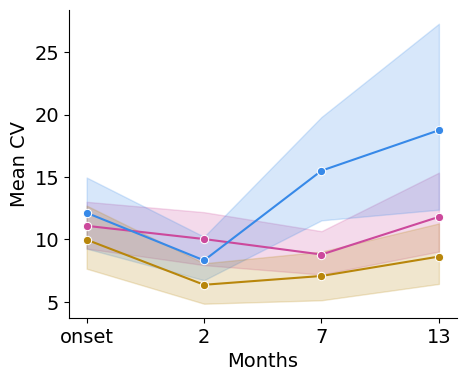

In [14]:
linear_vis_cv(ratings, custom_palette)

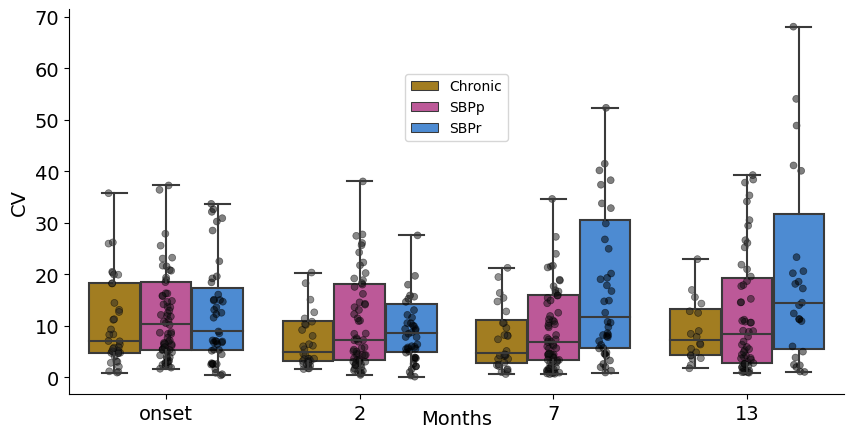

In [15]:
boxplot_cv(ratings, custom_palette)

In [16]:
def check_missing_visits(df):

    # If you already created a "selected" df (run_02 preferred), use that here:
    # df = selected

    expected = ["visit1", "visit2", "visit3", "visit4"]

    sbpr = df[df["group"] == "SBPr"].copy()

    # Per subject: which visits present?
    visits_per_subj = (sbpr.groupby("subject")["visit"]
                        .agg(lambda v: sorted(set(v)))
                        .rename("present_visits"))

    # Per subject: which visits missing?
    def missing(v):
        return [x for x in expected if x not in set(v)]

    missing_per_subj = visits_per_subj.apply(missing).rename("missing_visits")

    report = pd.concat([visits_per_subj, missing_per_subj], axis=1)

    # Specifically who is missing visit3 or visit4
    missing_v3 = report[report["missing_visits"].apply(lambda m: "visit3" in m)]
    missing_v4 = report[report["missing_visits"].apply(lambda m: "visit4" in m)]

    print("SBPr subjects missing visit 3:")
    print(missing_v3.index.tolist())
    print("\nSBPr subjects missing visit 4:")
    print(missing_v4.index.tolist())

    # Optional: count table of how many visits each subject has
    counts = sbpr.groupby("subject")["visit"].nunique().value_counts().sort_index()
    print("\n#SBPr subjects by number of visits present:")
    print(counts)

check_missing_visits(ratings)


SBPr subjects missing visit 3:
['sub-001', 'sub-026']

SBPr subjects missing visit 4:
['sub-002', 'sub-018', 'sub-020', 'sub-026', 'sub-027', 'sub-030', 'sub-045', 'sub-046', 'sub-051']

#SBPr subjects by number of visits present:
2     3
3     9
4    15
Name: visit, dtype: int64


### Average rating per patient across visits - visualisation and regression

/homes/gp565/short_term_variability_predicts_chronification/ratings_utils.py:238: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["1", "2", "3", "4"])


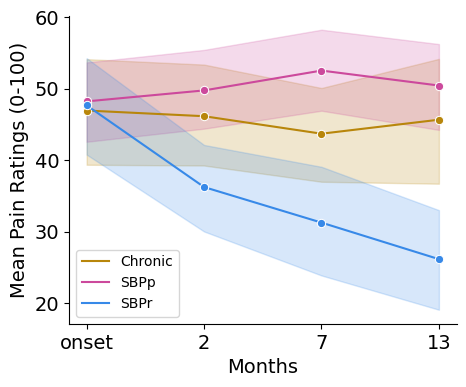

In [17]:
linear_vis_mean(ratings, custom_palette)

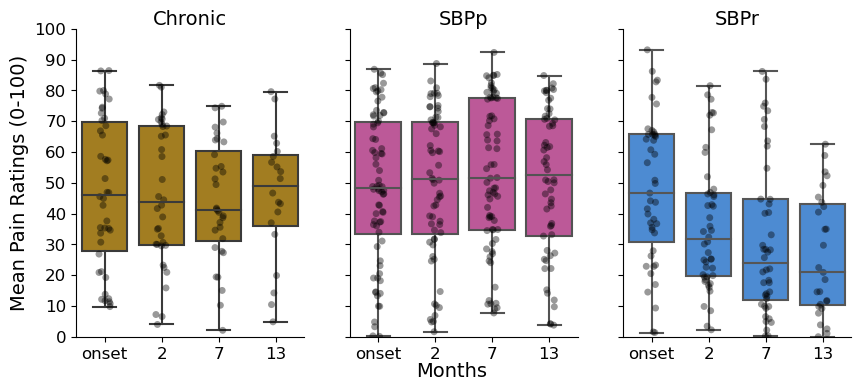

In [18]:
avg_rating_per_group(ratings, custom_palette)

### Perceived pain per group

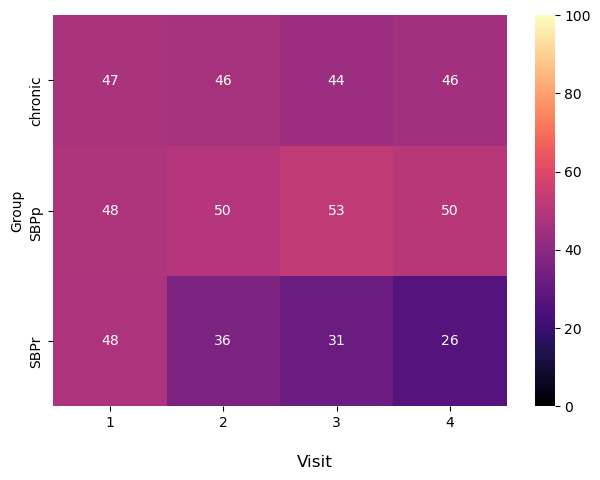

In [19]:
pivot = ratings.pivot_table(index="group", columns="visit", values="average_pain", aggfunc="mean")

# Reorder columns if needed
visit_order = ["visit1", "visit2", "visit3", "visit4"]
pivot = pivot[visit_order]

# Rename columns to numbers
pivot.columns = ["1", "2", "3", "4"]

# Plot heatmap
sns.heatmap(pivot, annot=True, cmap="magma", vmin=0, vmax=100)

# Apply clean labels
plt.ylabel("Group")
plt.xlabel("")            # Remove default label
plt.gcf().supxlabel("Visit")  # Add centered label below heatmap

plt.tight_layout()
plt.show()

### Choosing a measure based on statistics

<AxesSubplot:>

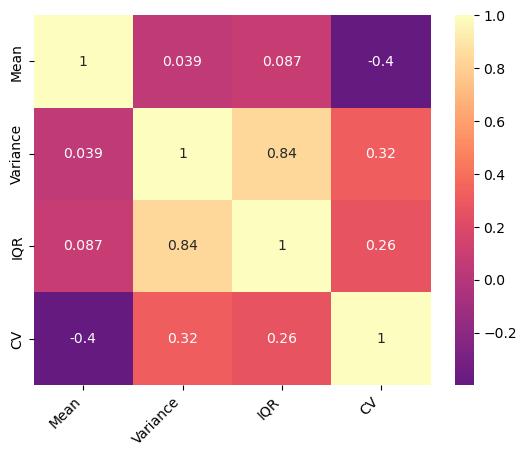

In [20]:
figure_name_mapping = {"average_pain": "Mean",
                       "ratings_std": "Standard Deviation",
                       "ratings_variance": "Variance",
                       "CV": "CV",
                       "IQR" : "IQR"
                       }
visit1_data = ratings[ratings["visit"] == "visit1"]
df_subset = visit1_data[["average_pain", "ratings_variance", "IQR", "CV"]].dropna()
corr = df_subset.corr()
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels slightly for better spacing
plt.yticks(rotation=0, va='center') 
corr.rename(index=figure_name_mapping, columns=figure_name_mapping, inplace=True)
sns.heatmap(corr, annot=True, cmap="magma", center=0)

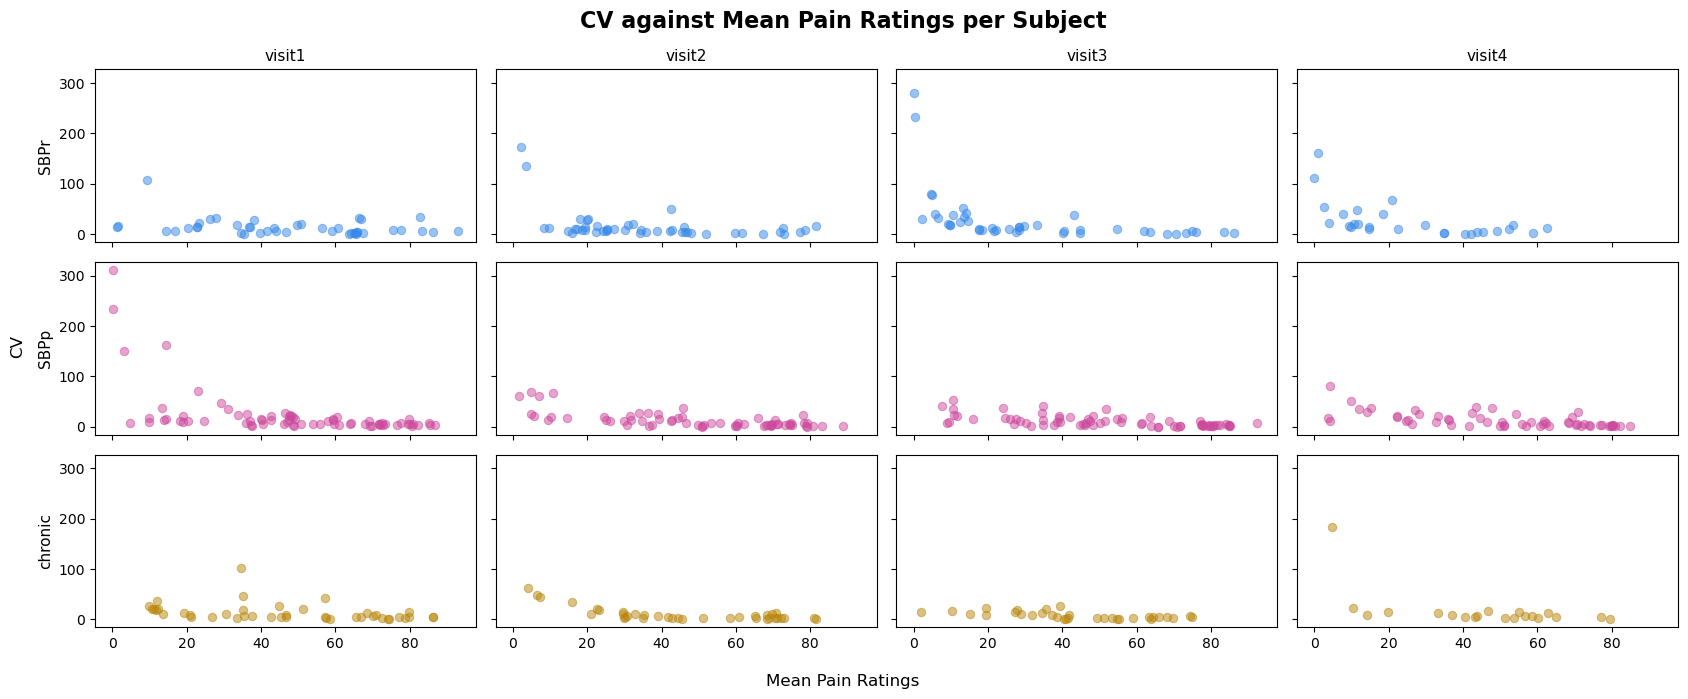

In [23]:
cv_vs_mean(ratings, custom_palette)

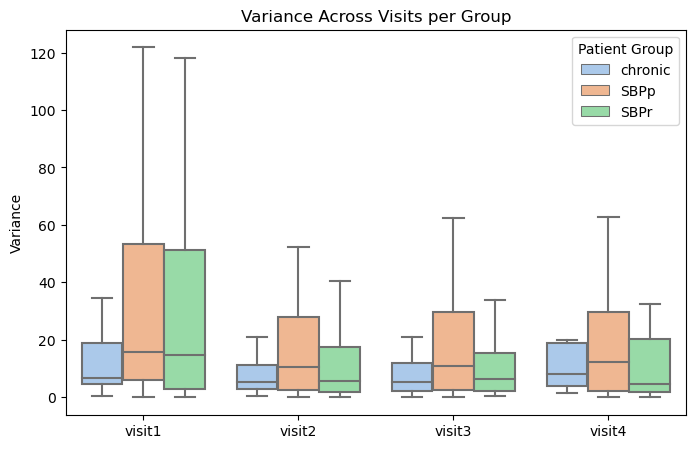

In [24]:
boxplot_variance(ratings)